In [2]:
import os
import kagglehub
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision.models import vgg16, VGG16_Weights
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

# ============================================================
# 2. DOWNLOAD DATASET
# ============================================================
path = kagglehub.dataset_download("abdulhasibuddin/uc-merced-land-use-dataset")
print("Dataset path:", path)

Dataset path: /kaggle/input/datasets/abdulhasibuddin/uc-merced-land-use-dataset


In [3]:

# ============================================================
# 3.  DATASET PATH 
# ============================================================
data_dir = os.path.join(path, "UCMerced_LandUse", "Images")

print("Folders inside dataset:", os.listdir(data_dir))

Folders inside dataset: ['airplane', 'tenniscourt', 'river', 'denseresidential', 'parkinglot', 'storagetanks', 'overpass', 'sparseresidential', 'mediumresidential', 'intersection', 'baseballdiamond', 'runway', 'chaparral', 'freeway', 'beach', 'buildings', 'harbor', 'mobilehomepark', 'forest', 'golfcourse', 'agricultural']


In [4]:
# ============================================================
# 4. TRANSFORMS (FROM PRETRAINED WEIGHTS)
# ============================================================
weights = VGG16_Weights.DEFAULT
transform = weights.transforms()


In [5]:

# ============================================================
# 5. LOAD DATASET
# ============================================================
dataset = datasets.ImageFolder(root=data_dir, transform=transform)

print("Total samples:", len(dataset))
print("Classes:", dataset.classes)
print("Number of classes:", len(dataset.classes))


Total samples: 2100
Classes: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']
Number of classes: 21


In [6]:
# ============================================================
# 6. TRAIN / VAL SPLIT
# ============================================================
indices = list(range(len(dataset)))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=dataset.targets,
    random_state=42
)

train_dataset = Subset(dataset, train_idx)
val_dataset   = Subset(dataset, val_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)


In [7]:

# ============================================================
# 7. DEVICE
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [8]:

# ============================================================
# 8. LOAD PRETRAINED VGG16
# ============================================================
model = vgg16(weights=weights)

# Freeze most layers
for param in model.features.parameters():
    param.requires_grad = False

# Unfreeze last few layers (fine-tuning)
for param in model.features[-8:].parameters():
    param.requires_grad = True

# Replace classifier with Dropout
NUM_CLASSES = len(dataset.classes)

model.classifier[6] = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(4096, NUM_CLASSES)
)

model = model.to(device)

# ============================================================
# 9. LOSS, OPTIMIZER, SCHEDULER
# ============================================================
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=5, gamma=0.1
)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 209MB/s] 


In [9]:
# ============================================================
# 10. TRAINING LOOP
# ============================================================
EPOCHS = 15
best_val_acc = 0

for epoch in range(EPOCHS):

    # ---------------- TRAIN ----------------
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    # ---------------- VALIDATION ----------------
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    # Step scheduler
    scheduler.step()

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_vgg16_ucmerced.pth")

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

# ============================================================
# 11. FINAL SAVE
# ============================================================
torch.save(model.state_dict(), "final_vgg16_ucmerced.pth")

print("\nTraining Complete!")
print(f"Validation Accuracy: {best_val_acc:.4f}")


Epoch [1/15]
Train Loss: 82.6796 | Train Acc: 0.5179
Val Loss: 5.4754 | Val Acc: 0.8714

Epoch [2/15]
Train Loss: 19.9291 | Train Acc: 0.8690
Val Loss: 4.2009 | Val Acc: 0.9024

Epoch [3/15]
Train Loss: 8.7578 | Train Acc: 0.9470
Val Loss: 2.4349 | Val Acc: 0.9405

Epoch [4/15]
Train Loss: 3.7841 | Train Acc: 0.9744
Val Loss: 2.4649 | Val Acc: 0.9381

Epoch [5/15]
Train Loss: 2.5672 | Train Acc: 0.9863
Val Loss: 1.8210 | Val Acc: 0.9571

Epoch [6/15]
Train Loss: 1.0659 | Train Acc: 0.9952
Val Loss: 1.6571 | Val Acc: 0.9595

Epoch [7/15]
Train Loss: 0.6460 | Train Acc: 0.9970
Val Loss: 1.6747 | Val Acc: 0.9667

Epoch [8/15]
Train Loss: 0.5721 | Train Acc: 0.9964
Val Loss: 1.6096 | Val Acc: 0.9643

Epoch [9/15]
Train Loss: 0.4336 | Train Acc: 0.9982
Val Loss: 1.6953 | Val Acc: 0.9595

Epoch [10/15]
Train Loss: 0.4229 | Train Acc: 0.9988
Val Loss: 1.7354 | Val Acc: 0.9571

Epoch [11/15]
Train Loss: 0.2926 | Train Acc: 0.9988
Val Loss: 1.7272 | Val Acc: 0.9571

Epoch [12/15]
Train Loss: 0

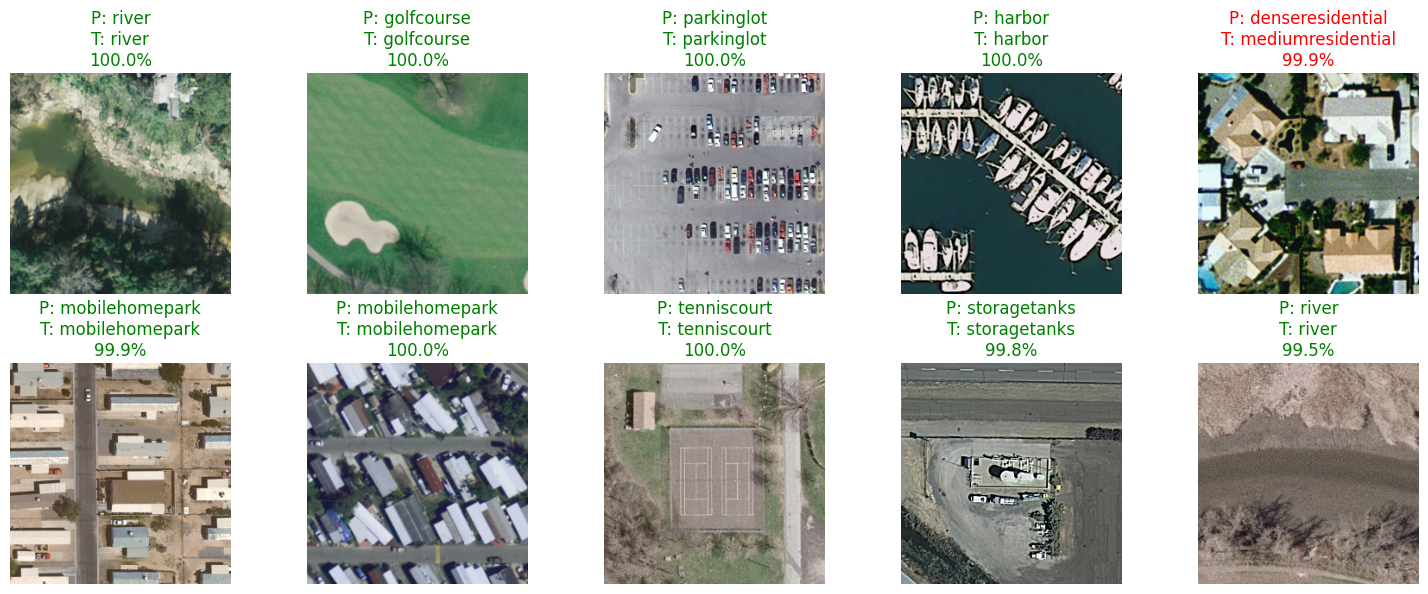

In [57]:
import matplotlib.pyplot as plt
import numpy as np
import random
from PIL import Image
import math

def visualize_predictions(num_images=10):
    model.eval()

    indices = random.sample(range(len(dataset)), num_images)

    
    cols = 5
    rows = math.ceil(num_images / cols)

    plt.figure(figsize=(15, 3 * rows))

    for i, idx in enumerate(indices):
        path, label = dataset.samples[idx]

        image = Image.open(path).convert("RGB")
        img_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(img_tensor)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            confidence, pred = torch.max(probs, 1)

        pred_class = class_names[pred.item()]
        true_class = class_names[label]
        conf = confidence.item() * 100

        plt.subplot(rows, cols, i+1)
        plt.imshow(image)

        color = "green" if pred_class == true_class else "red"

        plt.title(f"P: {pred_class}\nT: {true_class}\n{conf:.1f}%", color=color)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

visualize_predictions(10)

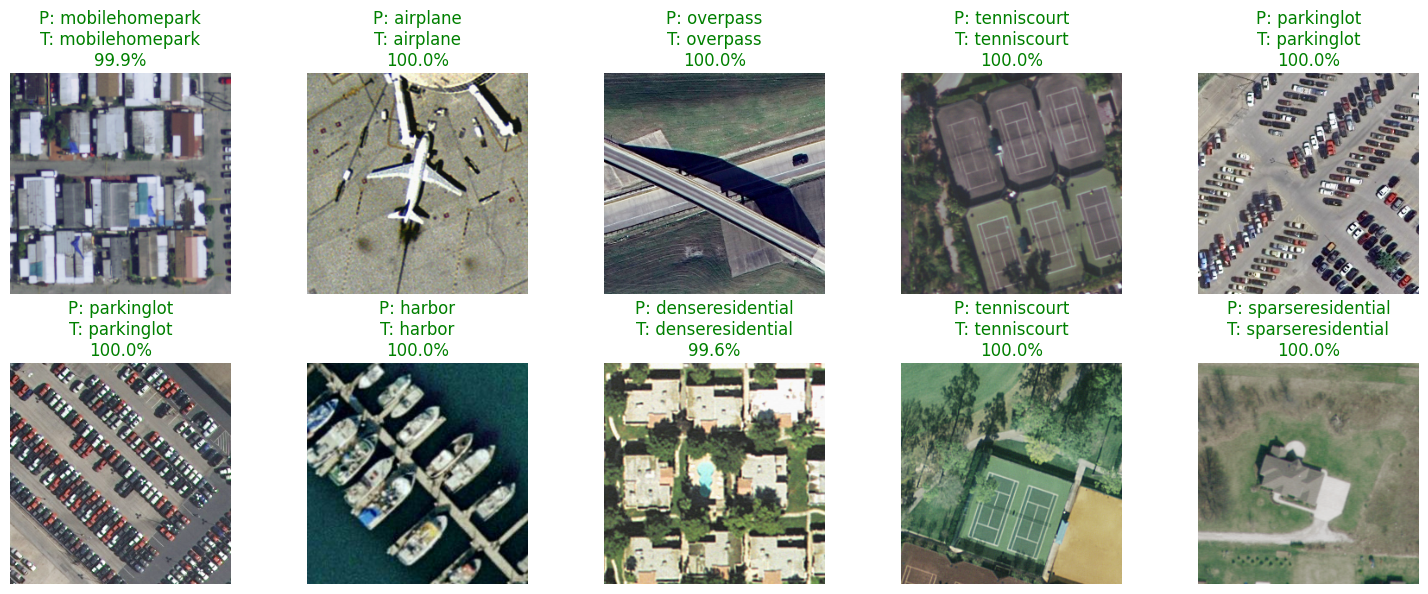

In [58]:
visualize_predictions(10)

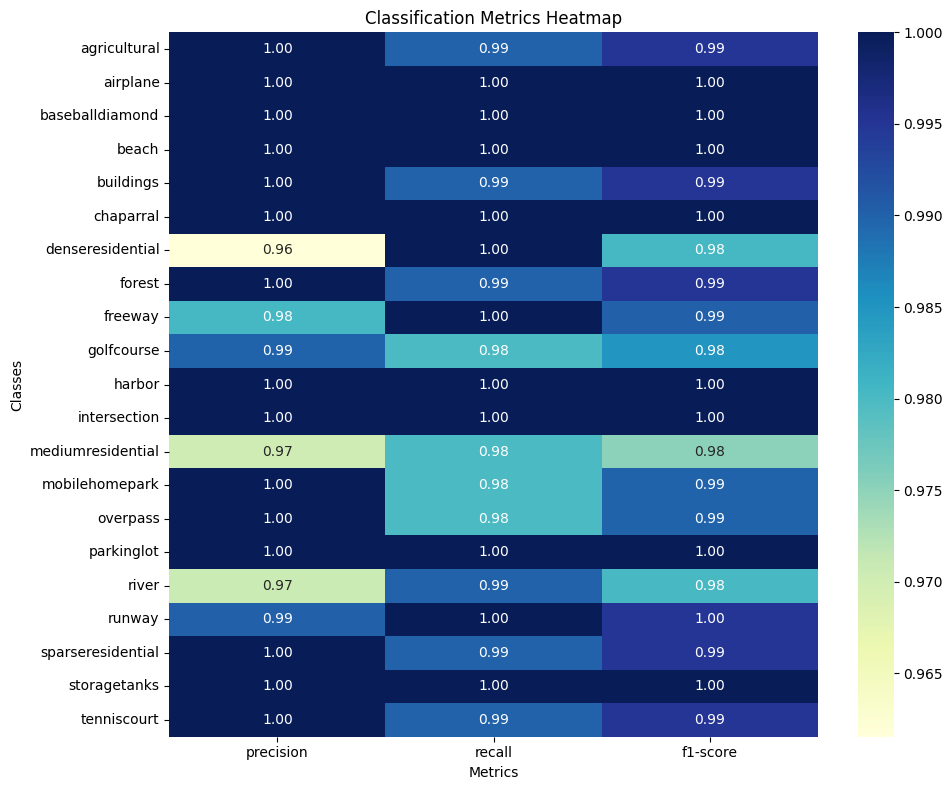

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report

def plot_metrics_heatmap():
    model.eval()

    all_preds = []
    all_labels = []

    for path, label in dataset.samples:
        image = Image.open(path).convert("RGB")
        img_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(img_tensor)
            _, pred = torch.max(outputs, 1)

        all_preds.append(pred.item())
        all_labels.append(label)

    report = classification_report(
        all_labels, all_preds,
        target_names=class_names,
        output_dict=True
    )

    df = pd.DataFrame(report).transpose()
    df = df.iloc[:-3][['precision','recall','f1-score']]

    plt.figure(figsize=(10,8))
    sns.heatmap(df, annot=True, cmap="YlGnBu", fmt=".2f")

    plt.title("Classification Metrics Heatmap")
    plt.xlabel("Metrics")
    plt.ylabel("Classes")

    plt.tight_layout()
    plt.show()
plot_metrics_heatmap()